# 01 — Analyse Exploratoire des Données (EDA)

Exploration des deux jeux de données du projet Bank Marketing.

- **Partie A** : Dataset Bank (UCI original)
- **Partie B** : Dataset Bank Additional (enrichi)
- **Partie C** : Analyse comparative

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.data_loader import load_bank, load_bank_additional, get_dataset_info
from src.eda import (
    summarize, analyze_missing,
    plot_target_distribution, plot_numerical_distributions,
    plot_categorical_distributions, plot_correlation_matrix,
)
from src.utils import set_seed

set_seed(42)
%matplotlib inline

---
## Partie A — Dataset Bank (UCI Original)

16 variables + cible, pas d'indicateurs économiques.

In [2]:
# Chargement du dataset Bank
df_bank = load_bank(full=True)
get_dataset_info(df_bank, name='Bank Dataset (full)')


--- Bank Dataset (full) ---
Shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Dtypes:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object
Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
First rows:
   age           job  marital  education 

### A.1 — Statistiques descriptives

In [3]:
summarize(df_bank)

            count         mean          std     min    25%    50%     75%  \
age       45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0   
balance   45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0   
day       45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0   
duration  45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0   
campaign  45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0   
pdays     45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0   
previous  45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0   

               max  
age           95.0  
balance   102127.0  
day           31.0  
duration    4918.0  
campaign      63.0  
pdays        871.0  
previous     275.0  
           count unique          top   freq
job        45211     12  blue-collar   9732
marital    45211      3      married  27214
education  45211      4    secondary  23202
default    45211      2           no  4

### A.2 — Valeurs 'unknown'

In [4]:
unknown_bank = analyze_missing(df_bank)

Colonnes contenant la valeur 'unknown' :
  poutcome: 36959 (81.7%)
  contact: 13020 (28.8%)
  education: 1857 (4.1%)
  job: 288 (0.6%)


### A.3 — Distribution de la cible

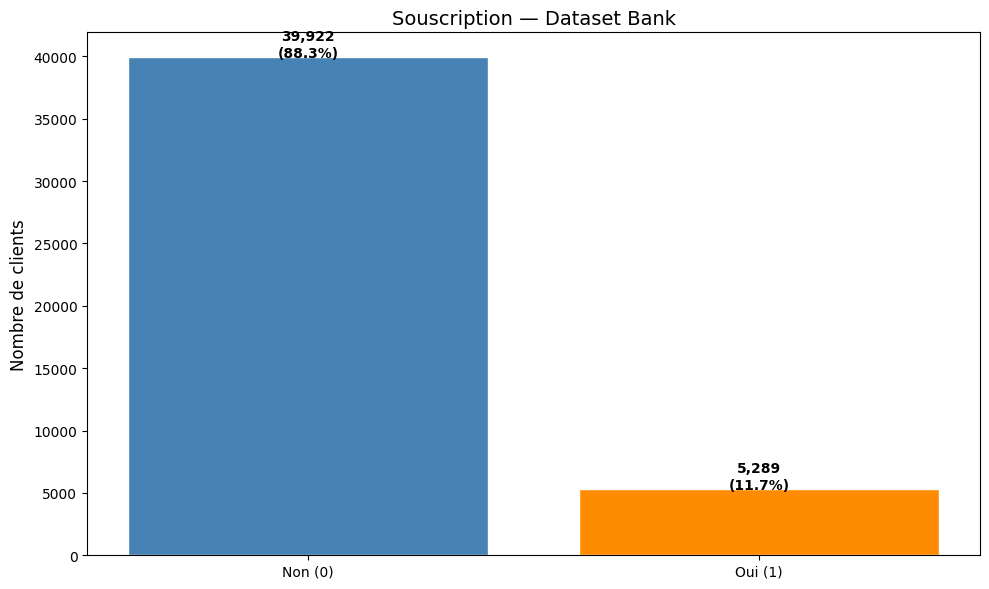

In [5]:
y_bank = df_bank['y'].map({'yes': 1, 'no': 0})
plot_target_distribution(y_bank, title='Souscription — Dataset Bank')

### A.4 — Variables numériques

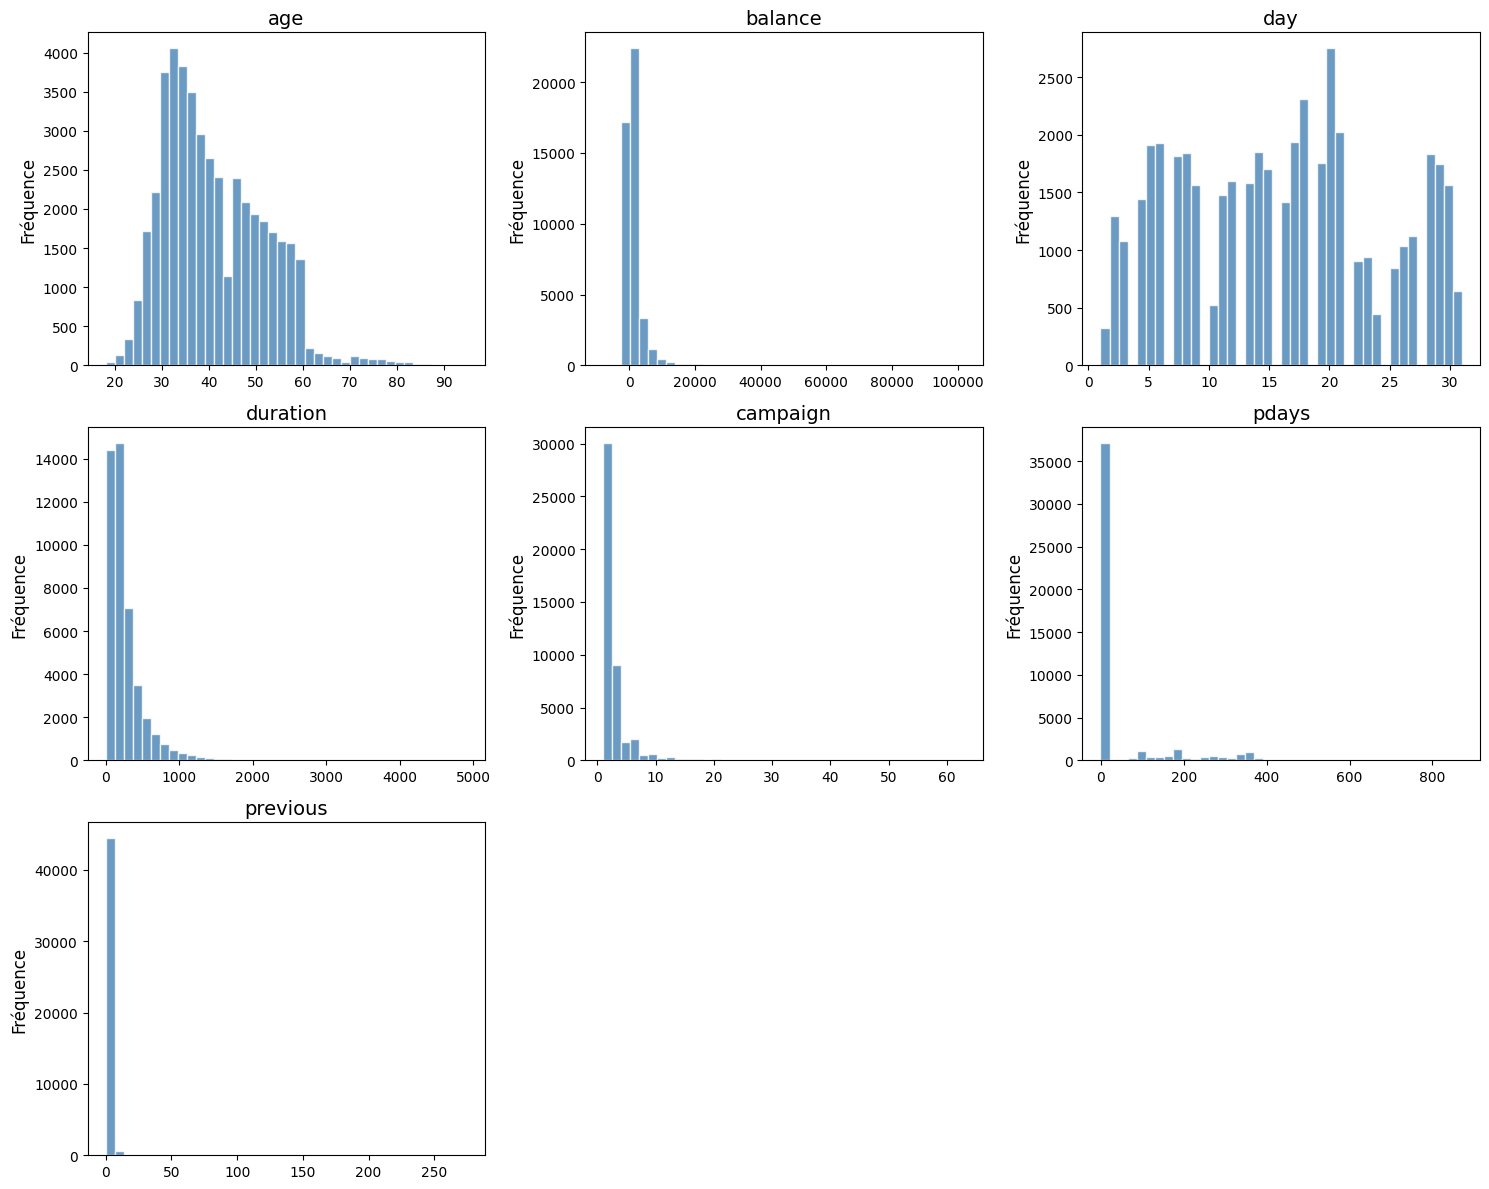

In [6]:
plot_numerical_distributions(df_bank)

### A.5 — Variables catégorielles

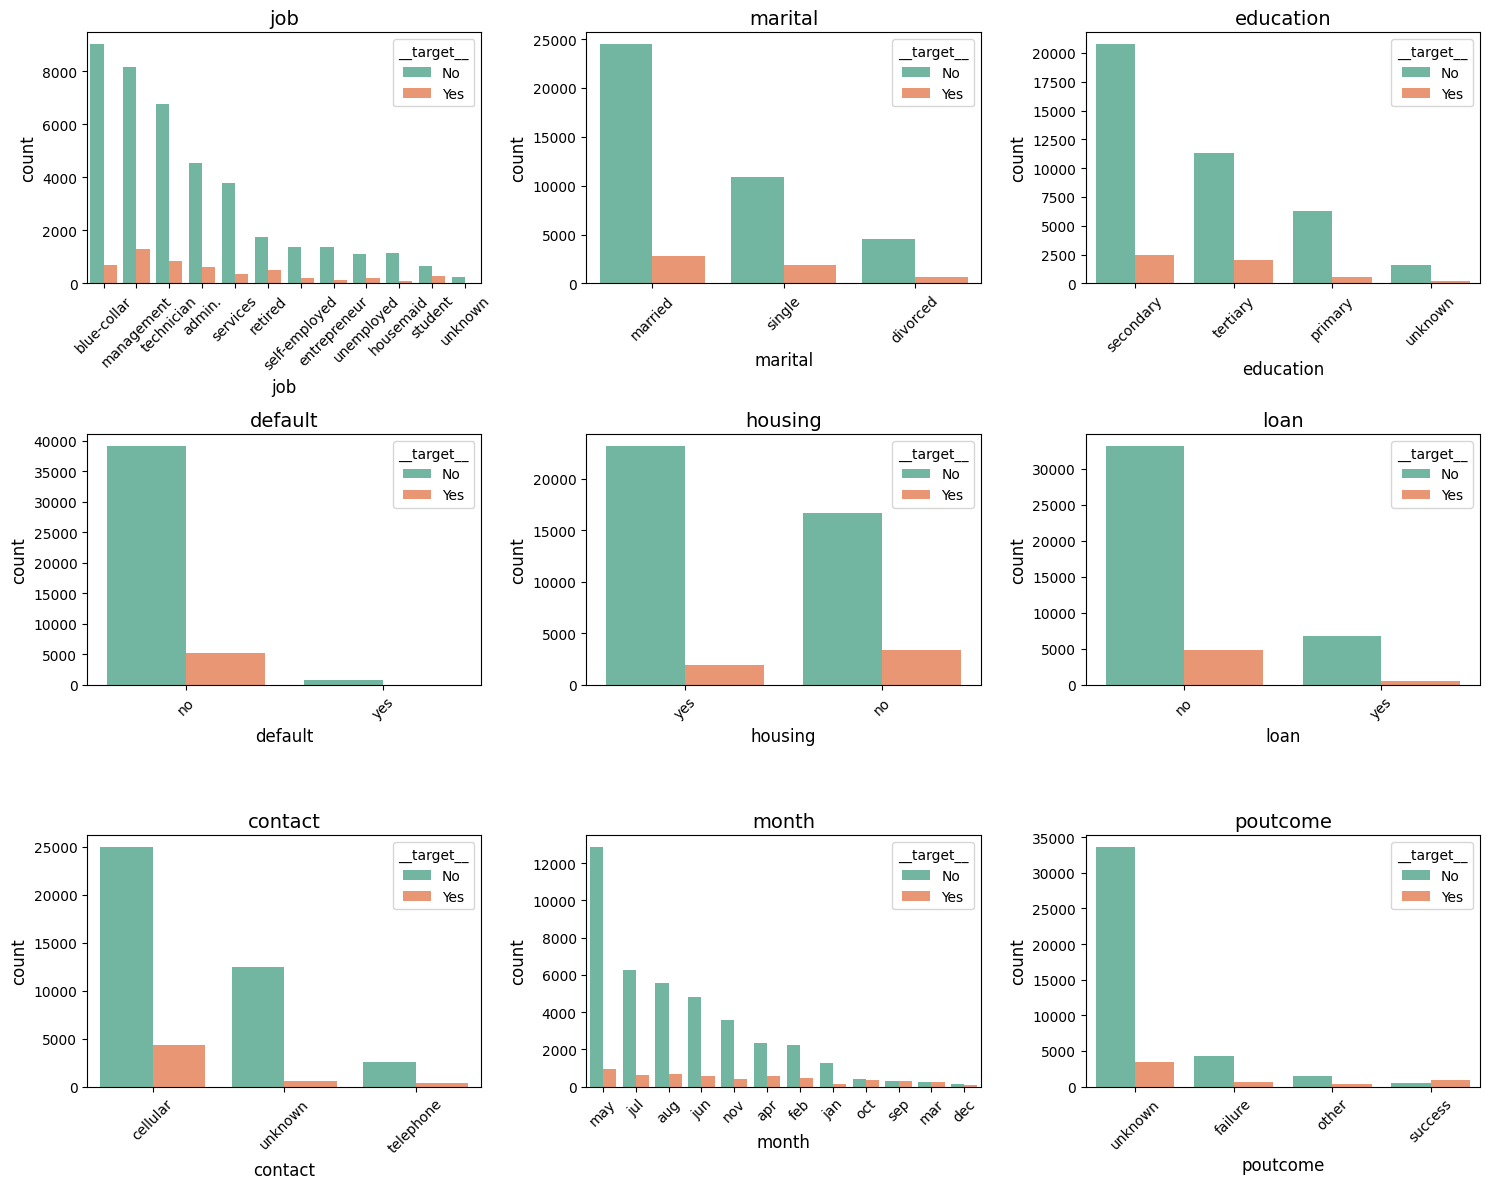

In [7]:
plot_categorical_distributions(df_bank, target=y_bank)

### A.6 — Matrice de corrélation

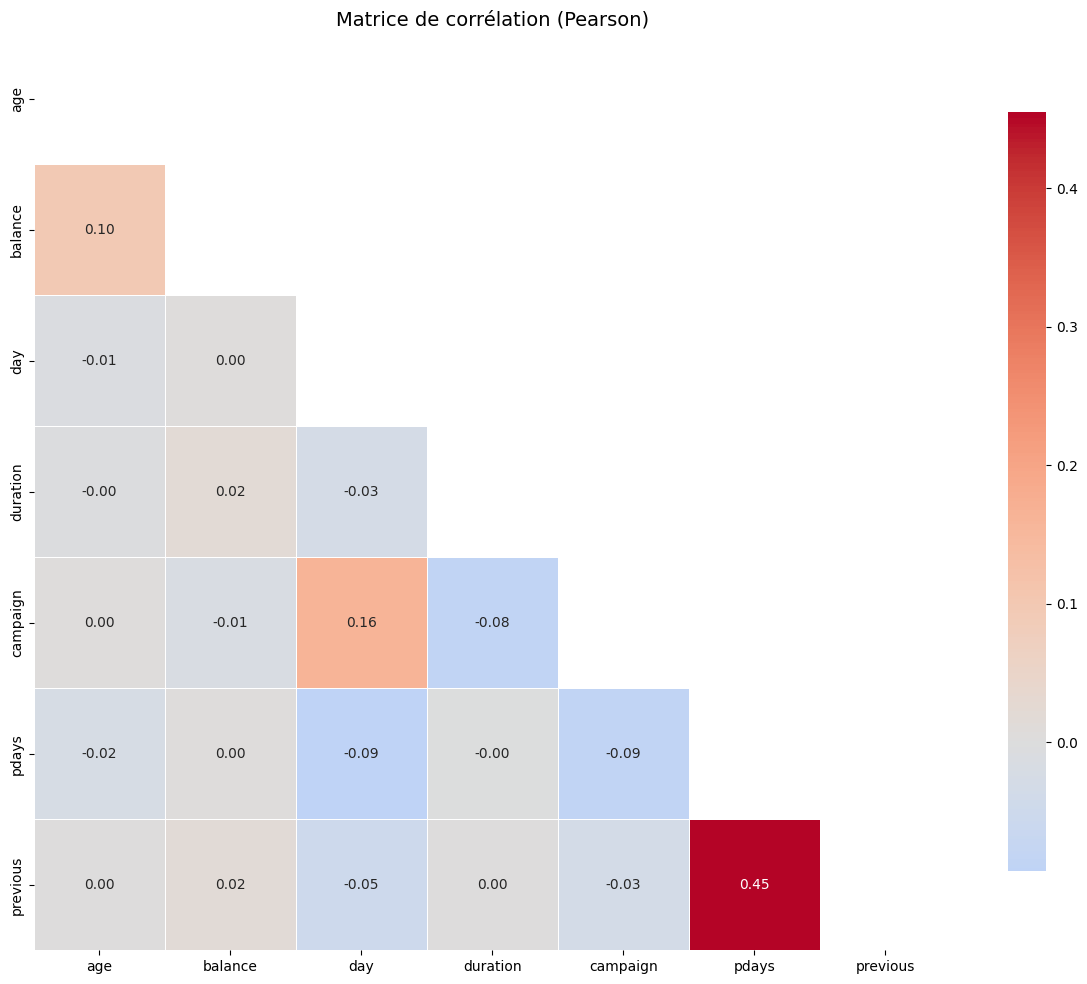

In [8]:
plot_correlation_matrix(df_bank)

### A.7 — Conclusions partie A

- À compléter...

---
## Partie B — Dataset Bank Additional (enrichi)

20 variables + cible, inclut 5 indicateurs socio-économiques :
- `emp.var.rate` — taux de variation de l'emploi
- `cons.price.idx` — indice des prix à la consommation
- `cons.conf.idx` — indice de confiance des consommateurs
- `euribor3m` — taux Euribor 3 mois
- `nr.employed` — nombre d'employés

In [9]:
# Chargement du dataset Bank Additional
df_add = load_bank_additional(full=True)
get_dataset_info(df_add, name='Bank Additional Dataset (full)')


--- Bank Additional Dataset (full) ---
Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Dtypes:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
Missing values:
age               0
job               0
marital           0
education         0
default           0
hou

### B.1 — Statistiques descriptives

In [10]:
summarize(df_add)

                  count         mean         std       min       25%  \
age             41188.0    40.024060   10.421250    17.000    32.000   
duration        41188.0   258.285010  259.279249     0.000   102.000   
campaign        41188.0     2.567593    2.770014     1.000     1.000   
pdays           41188.0   962.475454  186.910907     0.000   999.000   
previous        41188.0     0.172963    0.494901     0.000     0.000   
emp.var.rate    41188.0     0.081886    1.570960    -3.400    -1.800   
cons.price.idx  41188.0    93.575664    0.578840    92.201    93.075   
cons.conf.idx   41188.0   -40.502600    4.628198   -50.800   -42.700   
euribor3m       41188.0     3.621291    1.734447     0.634     1.344   
nr.employed     41188.0  5167.035911   72.251528  4963.600  5099.100   

                     50%       75%       max  
age               38.000    47.000    98.000  
duration         180.000   319.000  4918.000  
campaign           2.000     3.000    56.000  
pdays            99

### B.2 — Valeurs 'unknown'

In [11]:
unknown_add = analyze_missing(df_add)

Colonnes contenant la valeur 'unknown' :
  default: 8597 (20.9%)
  education: 1731 (4.2%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)
  job: 330 (0.8%)
  marital: 80 (0.2%)


### B.3 — Distribution de la cible

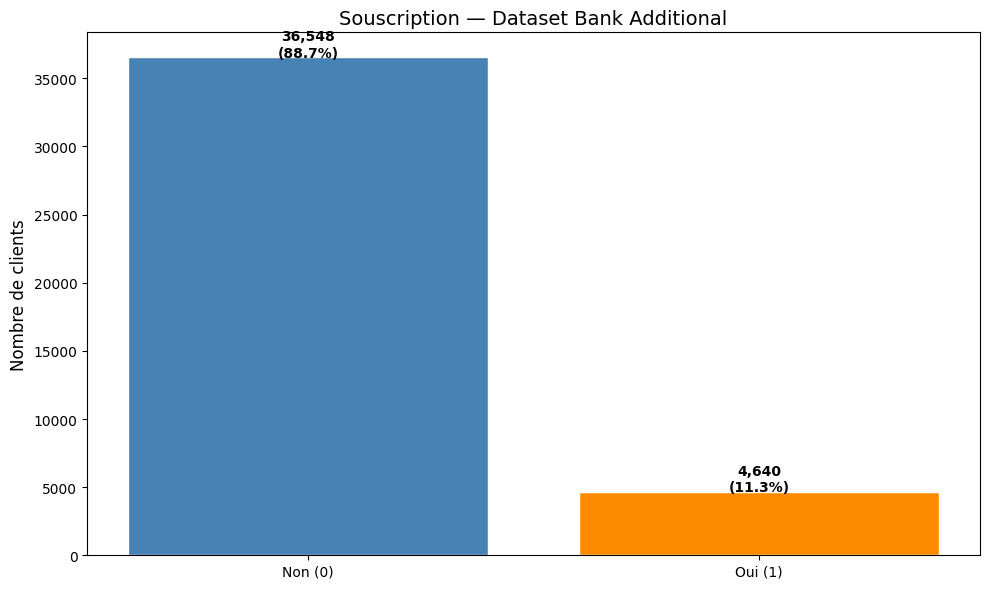

In [12]:
y_add = df_add['y'].map({'yes': 1, 'no': 0})
plot_target_distribution(y_add, title='Souscription — Dataset Bank Additional')

### B.4 — Variables numériques

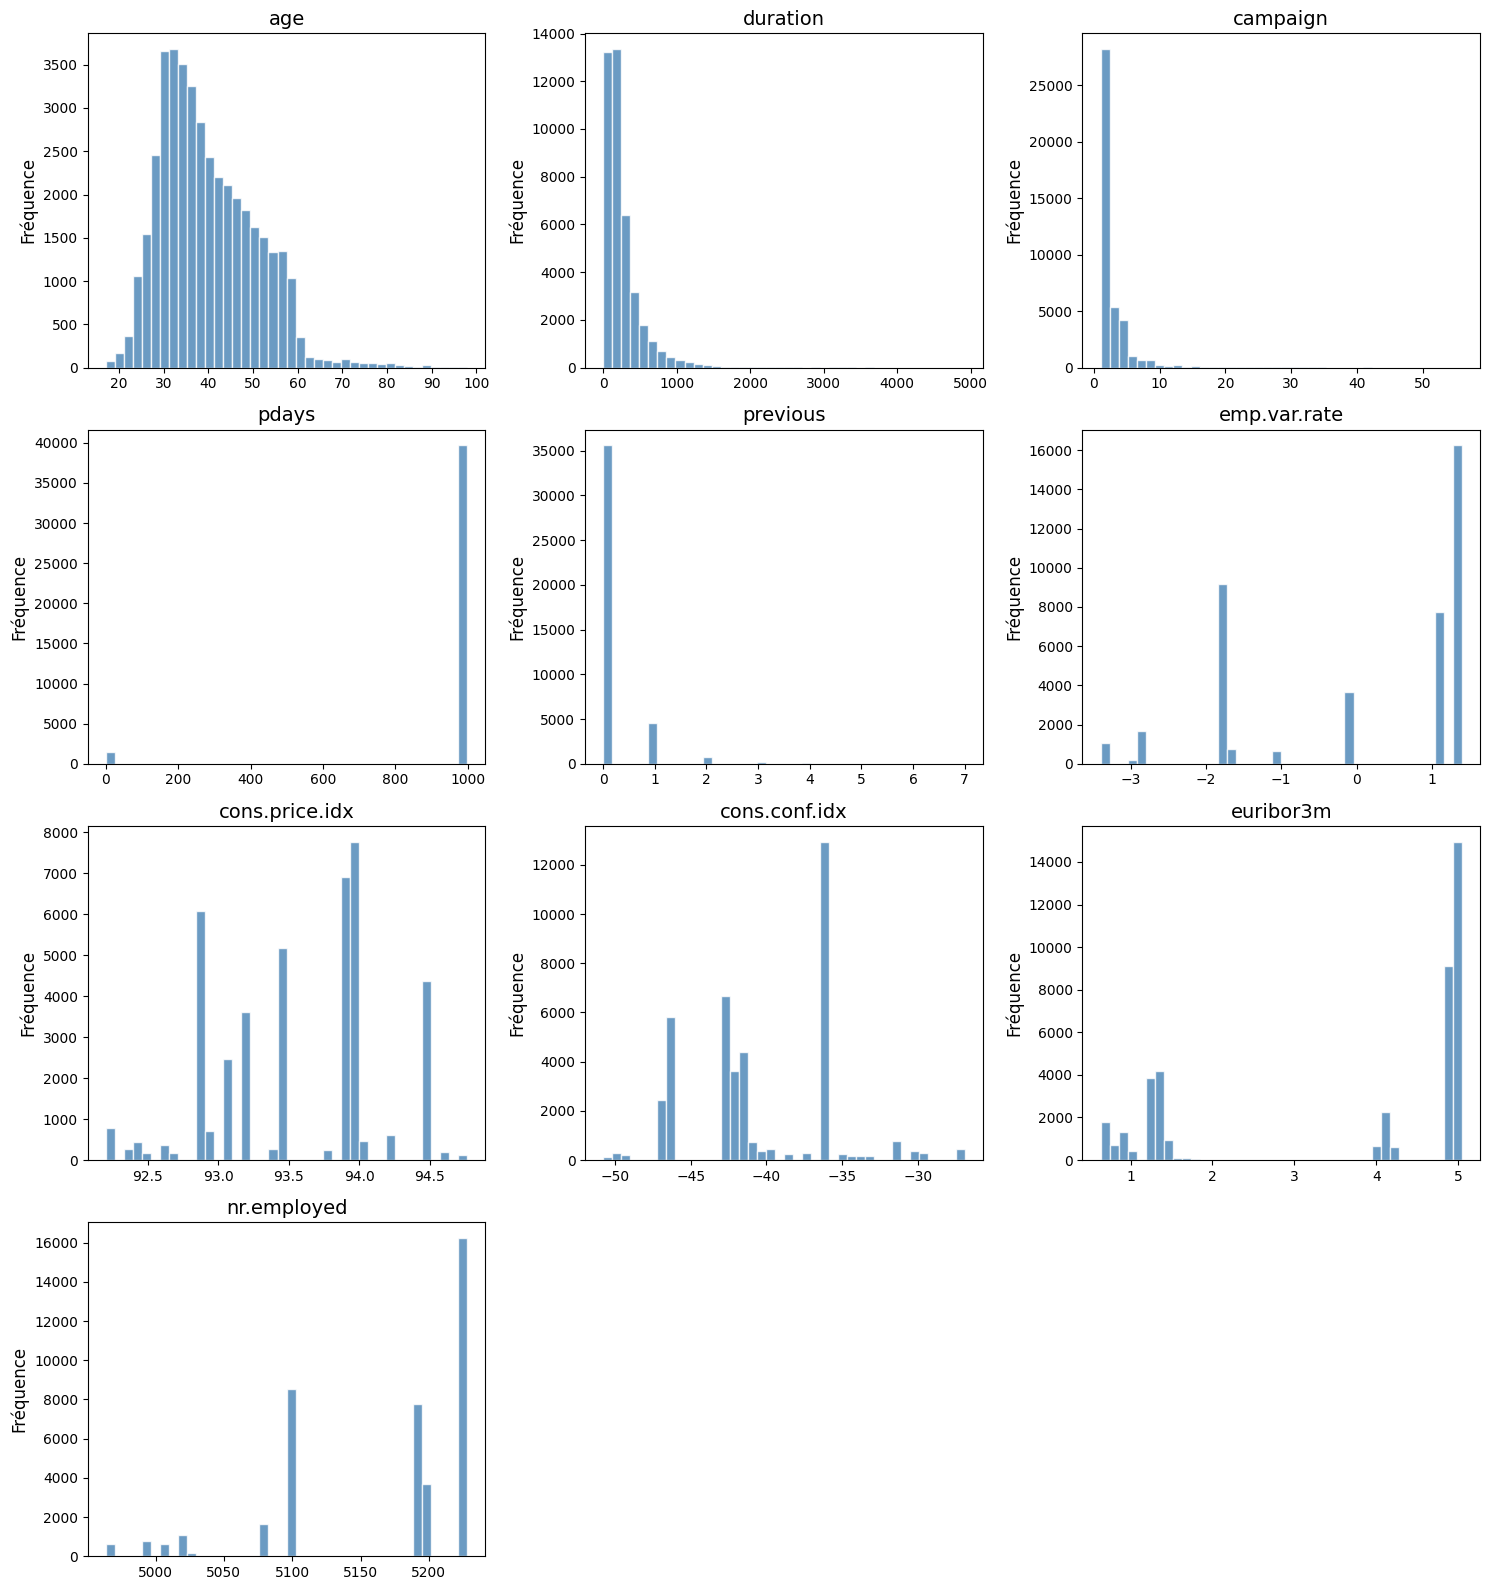

In [13]:
plot_numerical_distributions(df_add)

### B.5 — Focus : indicateurs socio-économiques

In [14]:
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print(df_add[econ_cols].describe().round(3).to_string())
print("\nCorrélations avec la cible :")
for col in econ_cols:
    corr = df_add[col].corr(y_add)
    print(f"  {col}: {corr:.4f}")

       emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
count     41188.000       41188.000      41188.000  41188.000    41188.000
mean          0.082          93.576        -40.503      3.621     5167.036
std           1.571           0.579          4.628      1.734       72.252
min          -3.400          92.201        -50.800      0.634     4963.600
25%          -1.800          93.075        -42.700      1.344     5099.100
50%           1.100          93.749        -41.800      4.857     5191.000
75%           1.400          93.994        -36.400      4.961     5228.100
max           1.400          94.767        -26.900      5.045     5228.100

Corrélations avec la cible :
  emp.var.rate: -0.2983
  cons.price.idx: -0.1362
  cons.conf.idx: 0.0549
  euribor3m: -0.3078
  nr.employed: -0.3547


### B.6 — Variables catégorielles

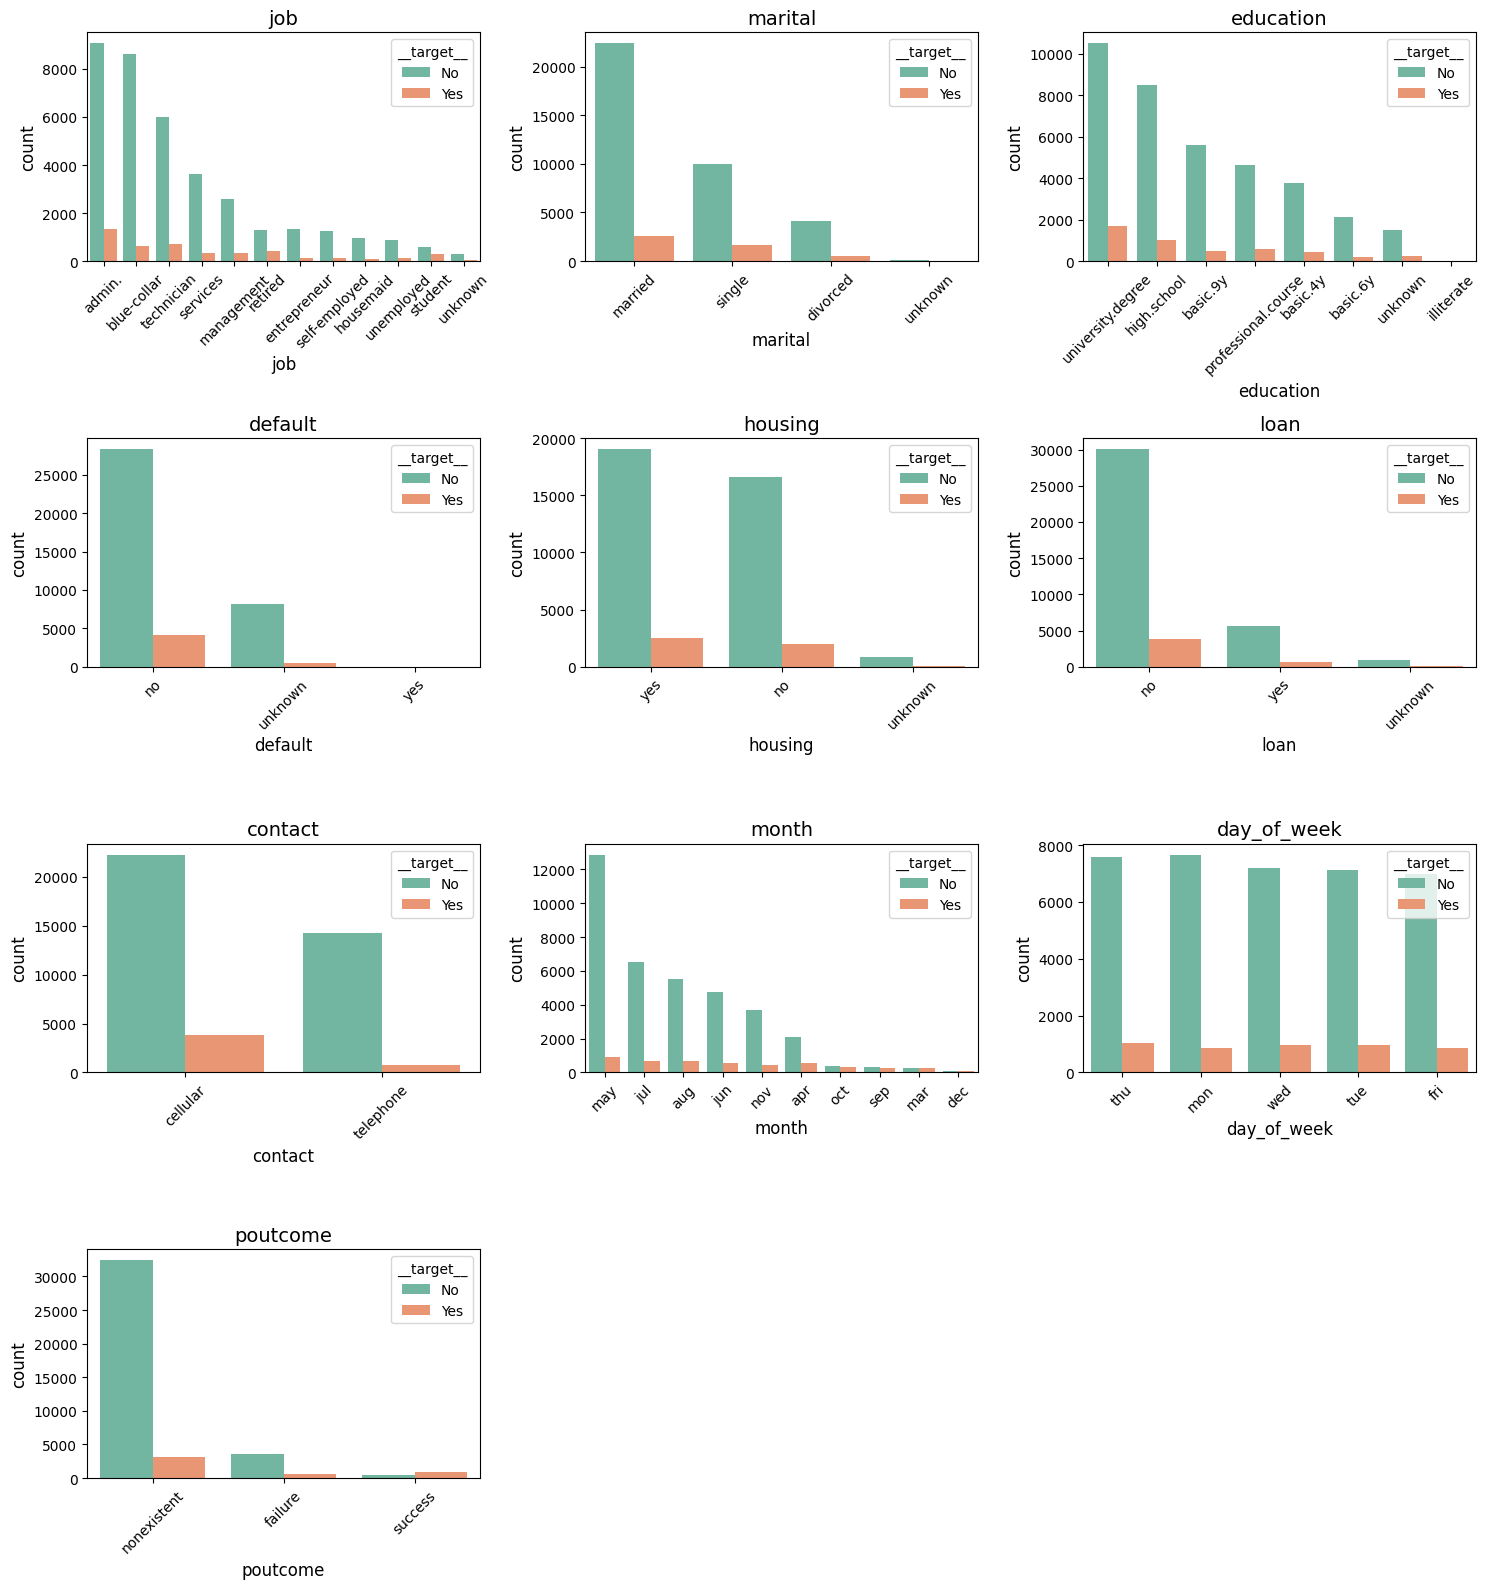

In [15]:
plot_categorical_distributions(df_add, target=y_add)

### B.7 — Matrice de corrélation

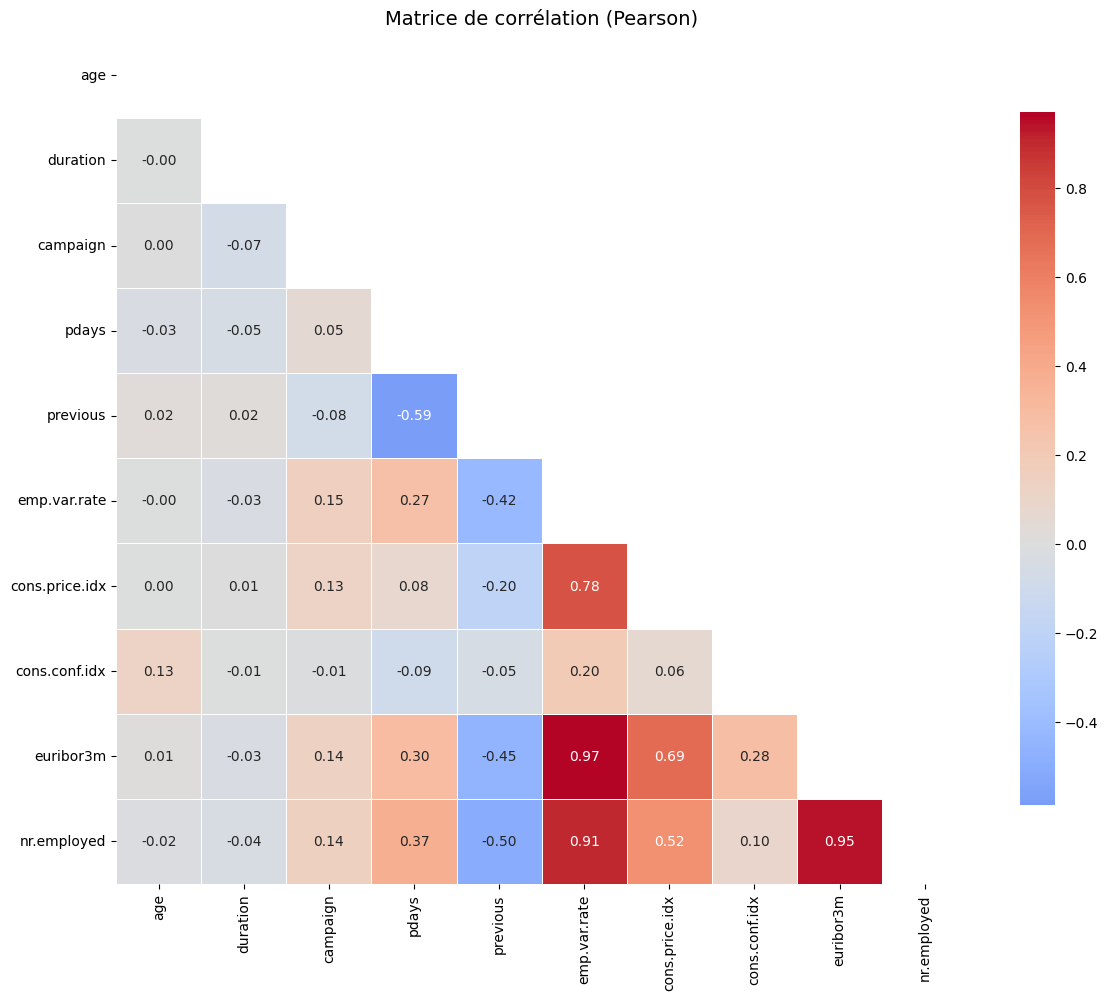

In [16]:
plot_correlation_matrix(df_add)

### B.8 — Conclusions partie B

- À compléter...

---
## Partie C — Analyse comparative

Comparaison rapide des deux datasets : taille, distribution de la cible, variables communes.

In [17]:
print(f"Instances  — Bank: {len(df_bank):,}  |  Additional: {len(df_add):,}")
print(f"Colonnes   — Bank: {df_bank.shape[1]}  |  Additional: {df_add.shape[1]}")
print(f"\nTaux de souscription (y='yes') :")
print(f"  Bank:       {(df_bank['y'] == 'yes').sum() / len(df_bank) * 100:.2f}%")
print(f"  Additional: {(df_add['y'] == 'yes').sum() / len(df_add) * 100:.2f}%")
print(f"\nVariables communes :")
common = set(df_bank.columns) & set(df_add.columns)
print(f"  {len(common)} colonnes : {sorted(common)}")
print(f"\nVariables uniquement dans Bank :")
only_bank = set(df_bank.columns) - set(df_add.columns)
print(f"  {sorted(only_bank)}")
print(f"\nVariables uniquement dans Additional :")
only_add = set(df_add.columns) - set(df_bank.columns)
print(f"  {sorted(only_add)}")

Instances  — Bank: 45,211  |  Additional: 41,188
Colonnes   — Bank: 17  |  Additional: 21

Taux de souscription (y='yes') :
  Bank:       11.70%
  Additional: 11.27%

Variables communes :
  15 colonnes : ['age', 'campaign', 'contact', 'default', 'duration', 'education', 'housing', 'job', 'loan', 'marital', 'month', 'pdays', 'poutcome', 'previous', 'y']

Variables uniquement dans Bank :
  ['balance', 'day']

Variables uniquement dans Additional :
  ['cons.conf.idx', 'cons.price.idx', 'day_of_week', 'emp.var.rate', 'euribor3m', 'nr.employed']


## Conclusions générales de l'EDA

- À compléter...

In [18]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.data_loader import load_bank, load_bank_additional, get_dataset_info
from src.eda import (
    summarize, analyze_missing,
    plot_target_distribution, plot_numerical_distributions,
    plot_categorical_distributions, plot_correlation_matrix,
)
from src.utils import set_seed

set_seed(42)
%matplotlib inline
print("✅ Imports OK")

✅ Imports OK


In [19]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.data_loader import load_bank, load_bank_additional, get_dataset_info
from src.eda import (
    summarize, analyze_missing,
    plot_target_distribution, plot_numerical_distributions,
    plot_categorical_distributions, plot_correlation_matrix,
)
from src.utils import set_seed

set_seed(42)
%matplotlib inline
print("✅ Imports OK")

✅ Imports OK


In [20]:
# Chargement du dataset Bank
df_bank = load_bank(full=True)
get_dataset_info(df_bank, name='Bank Dataset (full)')


--- Bank Dataset (full) ---
Shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Dtypes:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object
Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
First rows:
   age           job  marital  education 

In [21]:
summarize(df_bank)

            count         mean          std     min    25%    50%     75%  \
age       45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0   
balance   45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0   
day       45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0   
duration  45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0   
campaign  45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0   
pdays     45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0   
previous  45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0   

               max  
age           95.0  
balance   102127.0  
day           31.0  
duration    4918.0  
campaign      63.0  
pdays        871.0  
previous     275.0  
           count unique          top   freq
job        45211     12  blue-collar   9732
marital    45211      3      married  27214
education  45211      4    secondary  23202
default    45211      2           no  4

In [22]:
unknown_bank = analyze_missing(df_bank)

Colonnes contenant la valeur 'unknown' :
  poutcome: 36959 (81.7%)
  contact: 13020 (28.8%)
  education: 1857 (4.1%)
  job: 288 (0.6%)


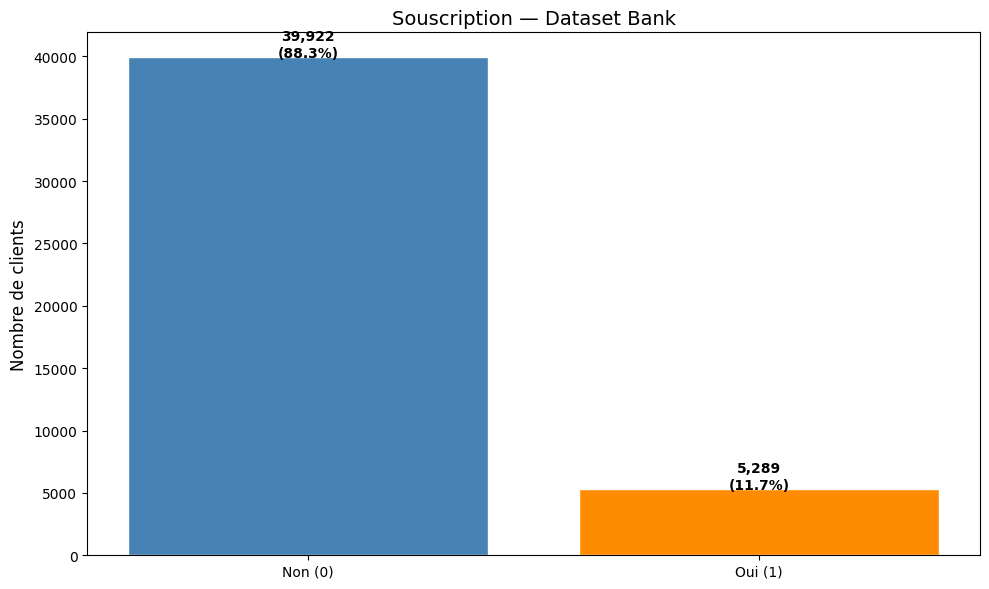

In [23]:
y_bank = df_bank['y'].map({'yes': 1, 'no': 0})
plot_target_distribution(y_bank, title='Souscription — Dataset Bank')

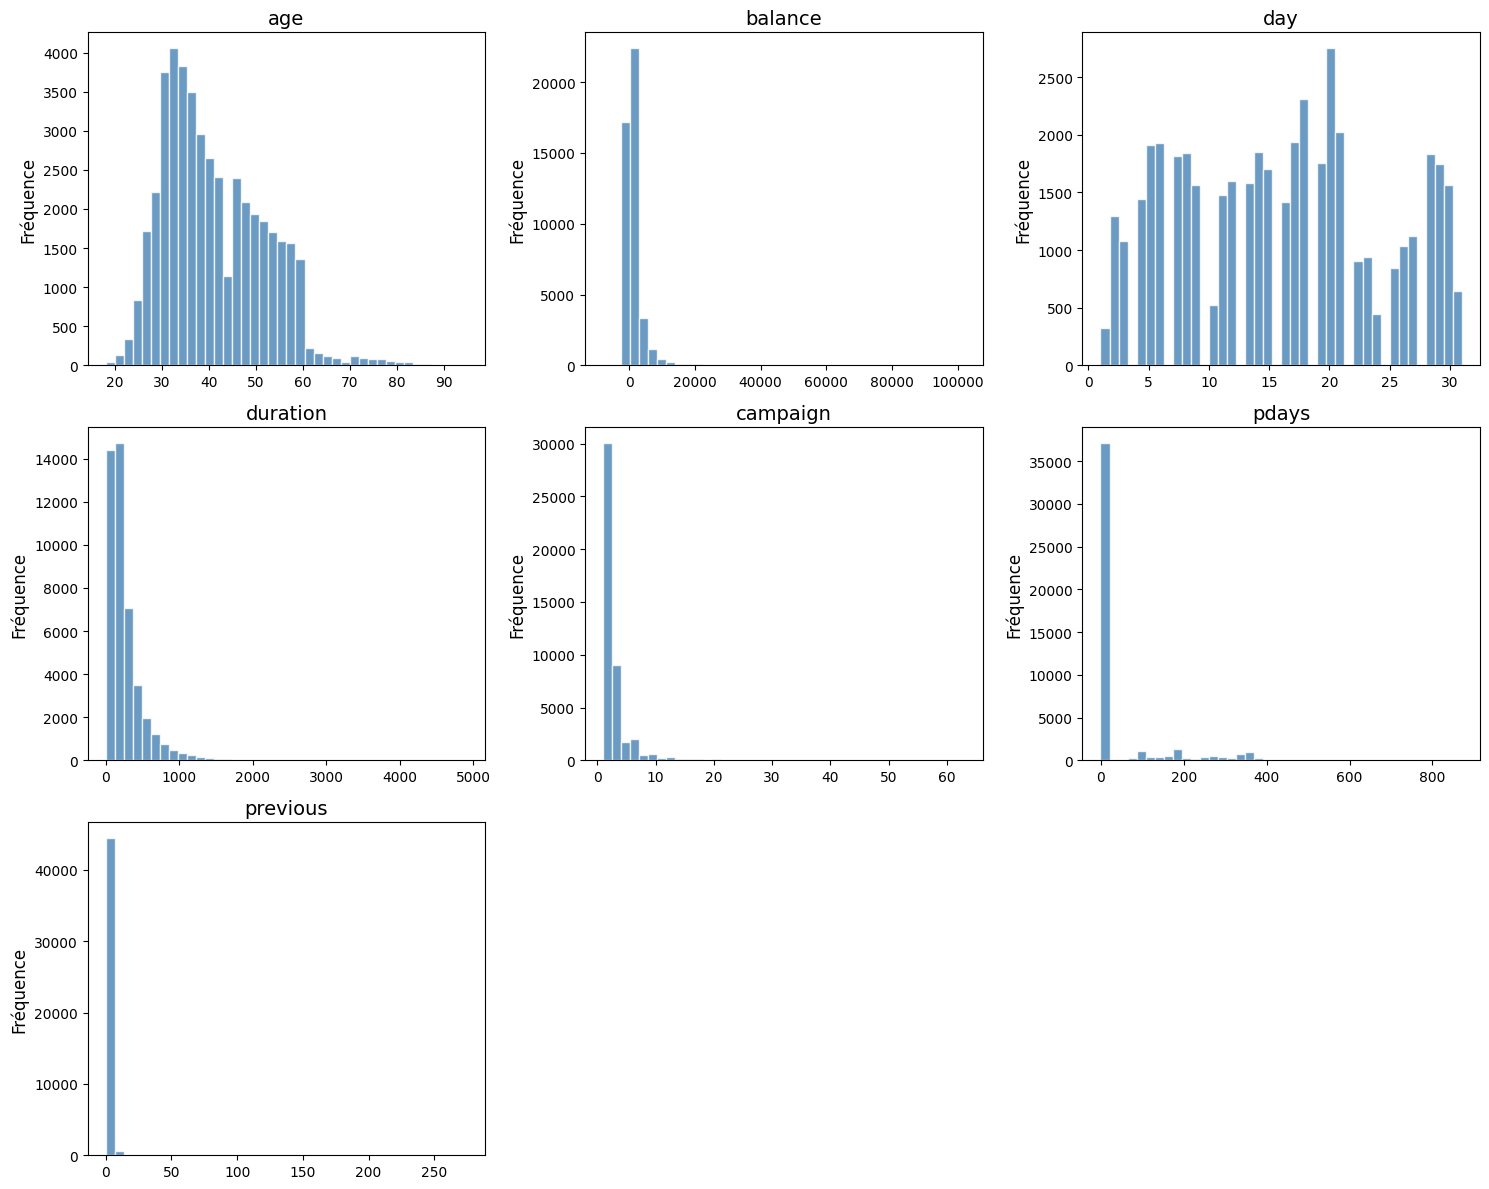

In [24]:
plot_numerical_distributions(df_bank)

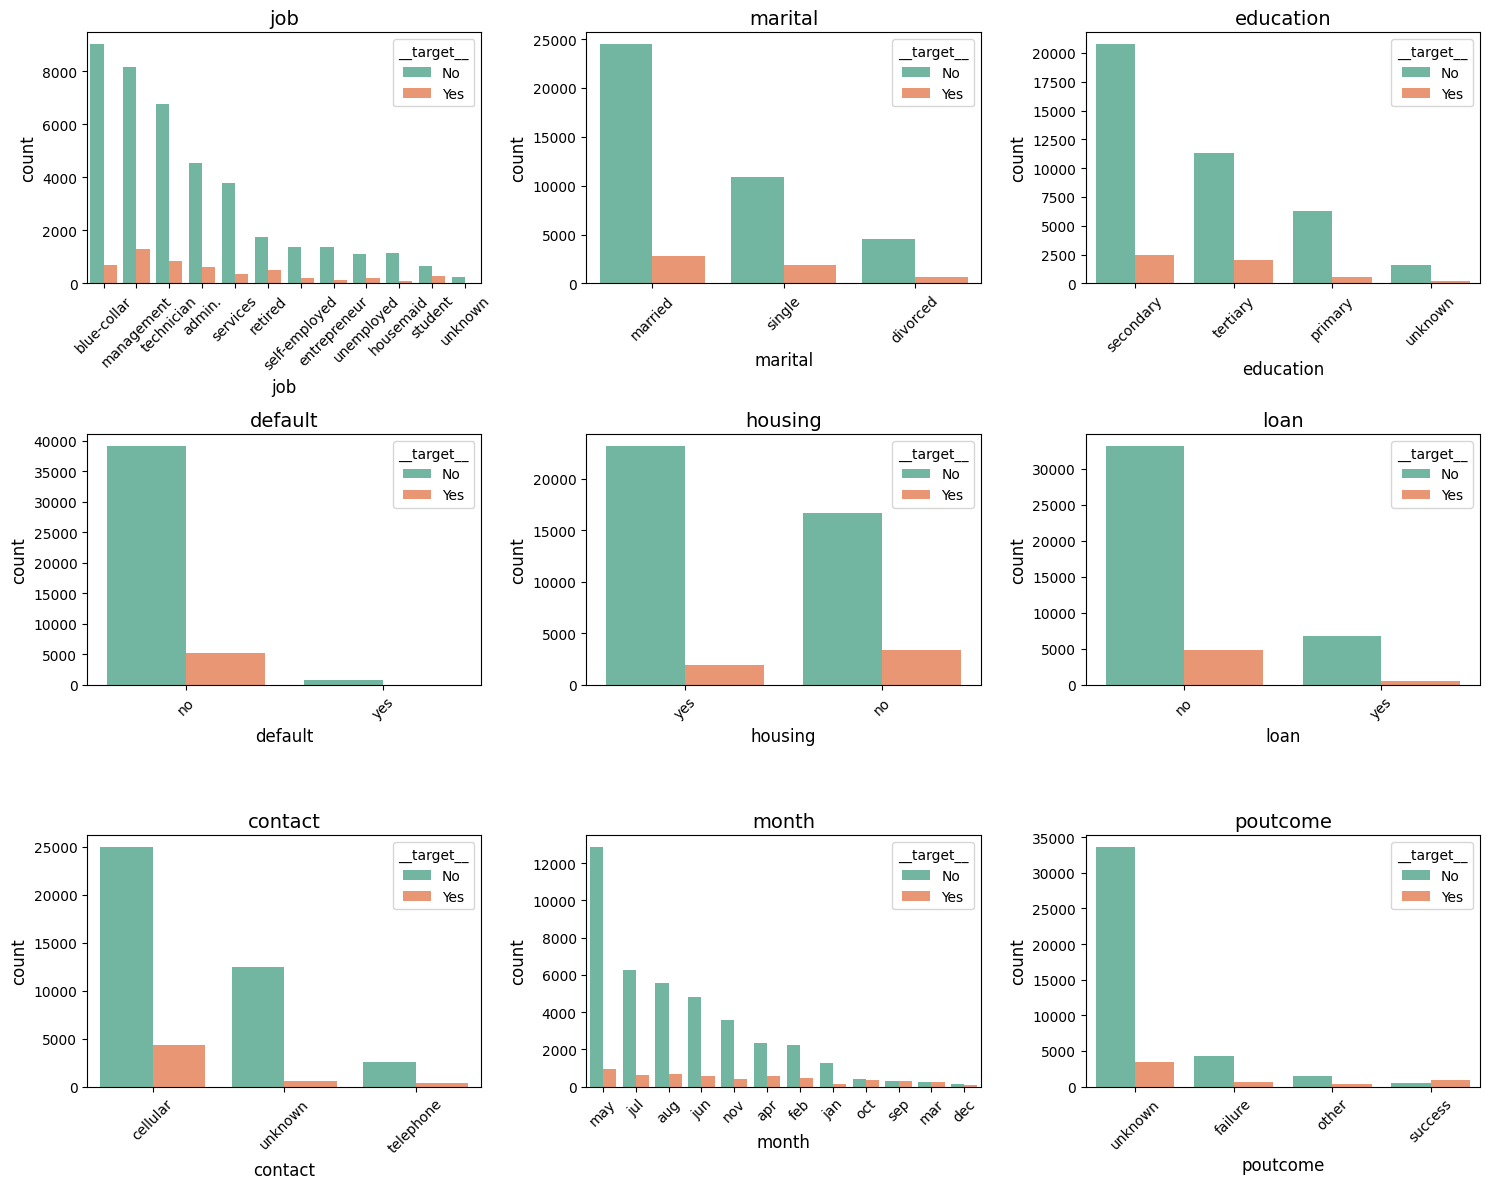

In [25]:
plot_categorical_distributions(df_bank, target=y_bank)

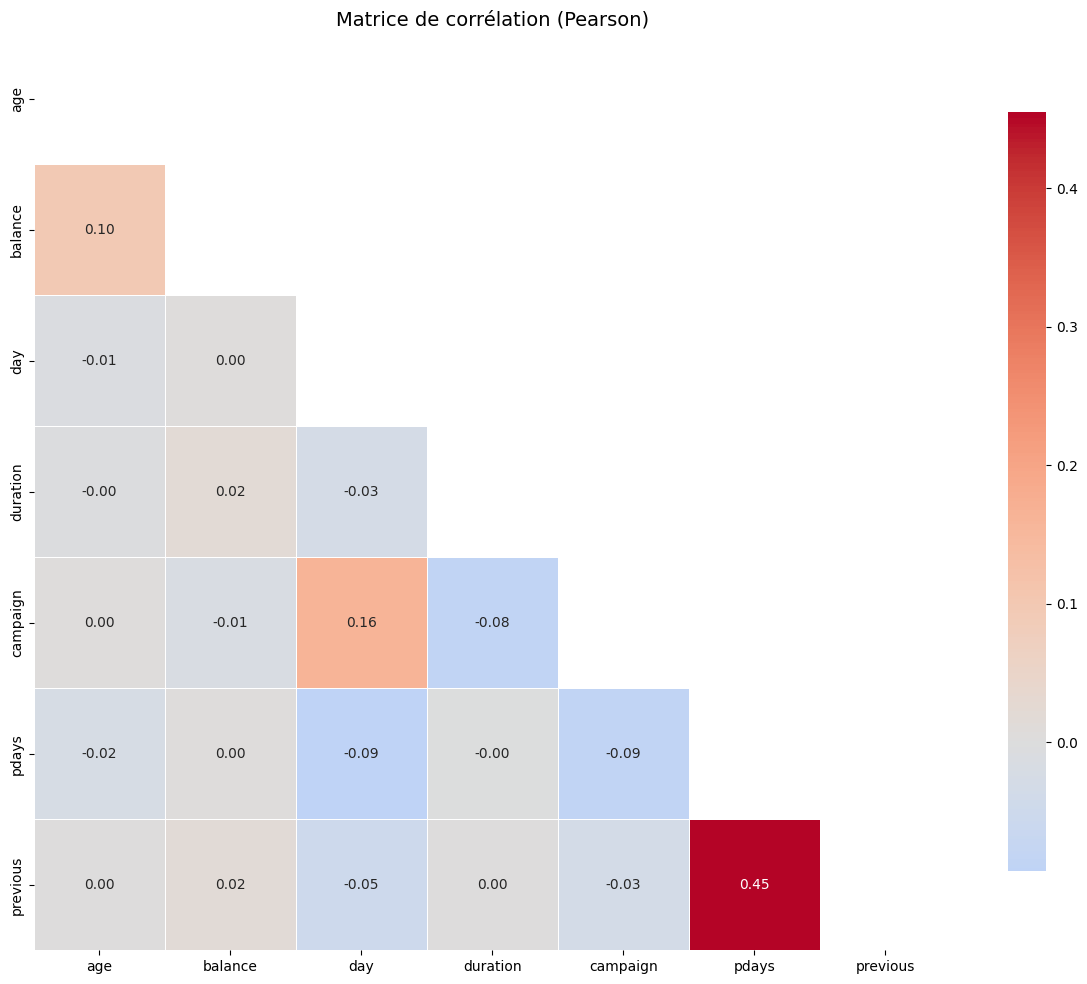

In [26]:
plot_correlation_matrix(df_bank)

In [27]:
# Chargement du dataset Bank Additional
df_add = load_bank_additional(full=True)
get_dataset_info(df_add, name='Bank Additional Dataset (full)')


--- Bank Additional Dataset (full) ---
Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Dtypes:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
Missing values:
age               0
job               0
marital           0
education         0
default           0
hou

In [28]:
summarize(df_add)

                  count         mean         std       min       25%  \
age             41188.0    40.024060   10.421250    17.000    32.000   
duration        41188.0   258.285010  259.279249     0.000   102.000   
campaign        41188.0     2.567593    2.770014     1.000     1.000   
pdays           41188.0   962.475454  186.910907     0.000   999.000   
previous        41188.0     0.172963    0.494901     0.000     0.000   
emp.var.rate    41188.0     0.081886    1.570960    -3.400    -1.800   
cons.price.idx  41188.0    93.575664    0.578840    92.201    93.075   
cons.conf.idx   41188.0   -40.502600    4.628198   -50.800   -42.700   
euribor3m       41188.0     3.621291    1.734447     0.634     1.344   
nr.employed     41188.0  5167.035911   72.251528  4963.600  5099.100   

                     50%       75%       max  
age               38.000    47.000    98.000  
duration         180.000   319.000  4918.000  
campaign           2.000     3.000    56.000  
pdays            99

In [29]:
unknown_add = analyze_missing(df_add)

Colonnes contenant la valeur 'unknown' :
  default: 8597 (20.9%)
  education: 1731 (4.2%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)
  job: 330 (0.8%)
  marital: 80 (0.2%)


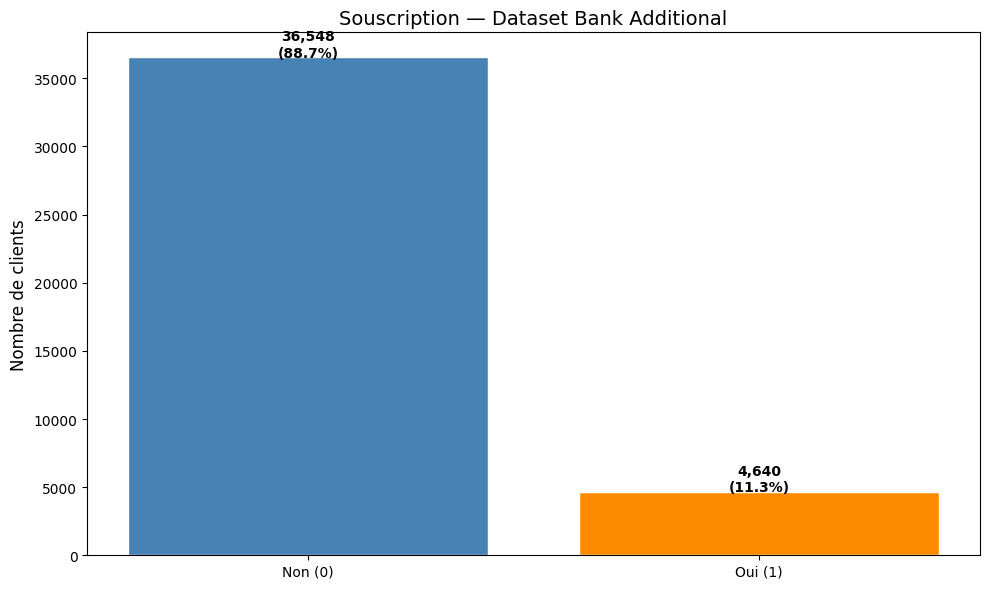

In [30]:
y_add = df_add['y'].map({'yes': 1, 'no': 0})
plot_target_distribution(y_add, title='Souscription — Dataset Bank Additional')

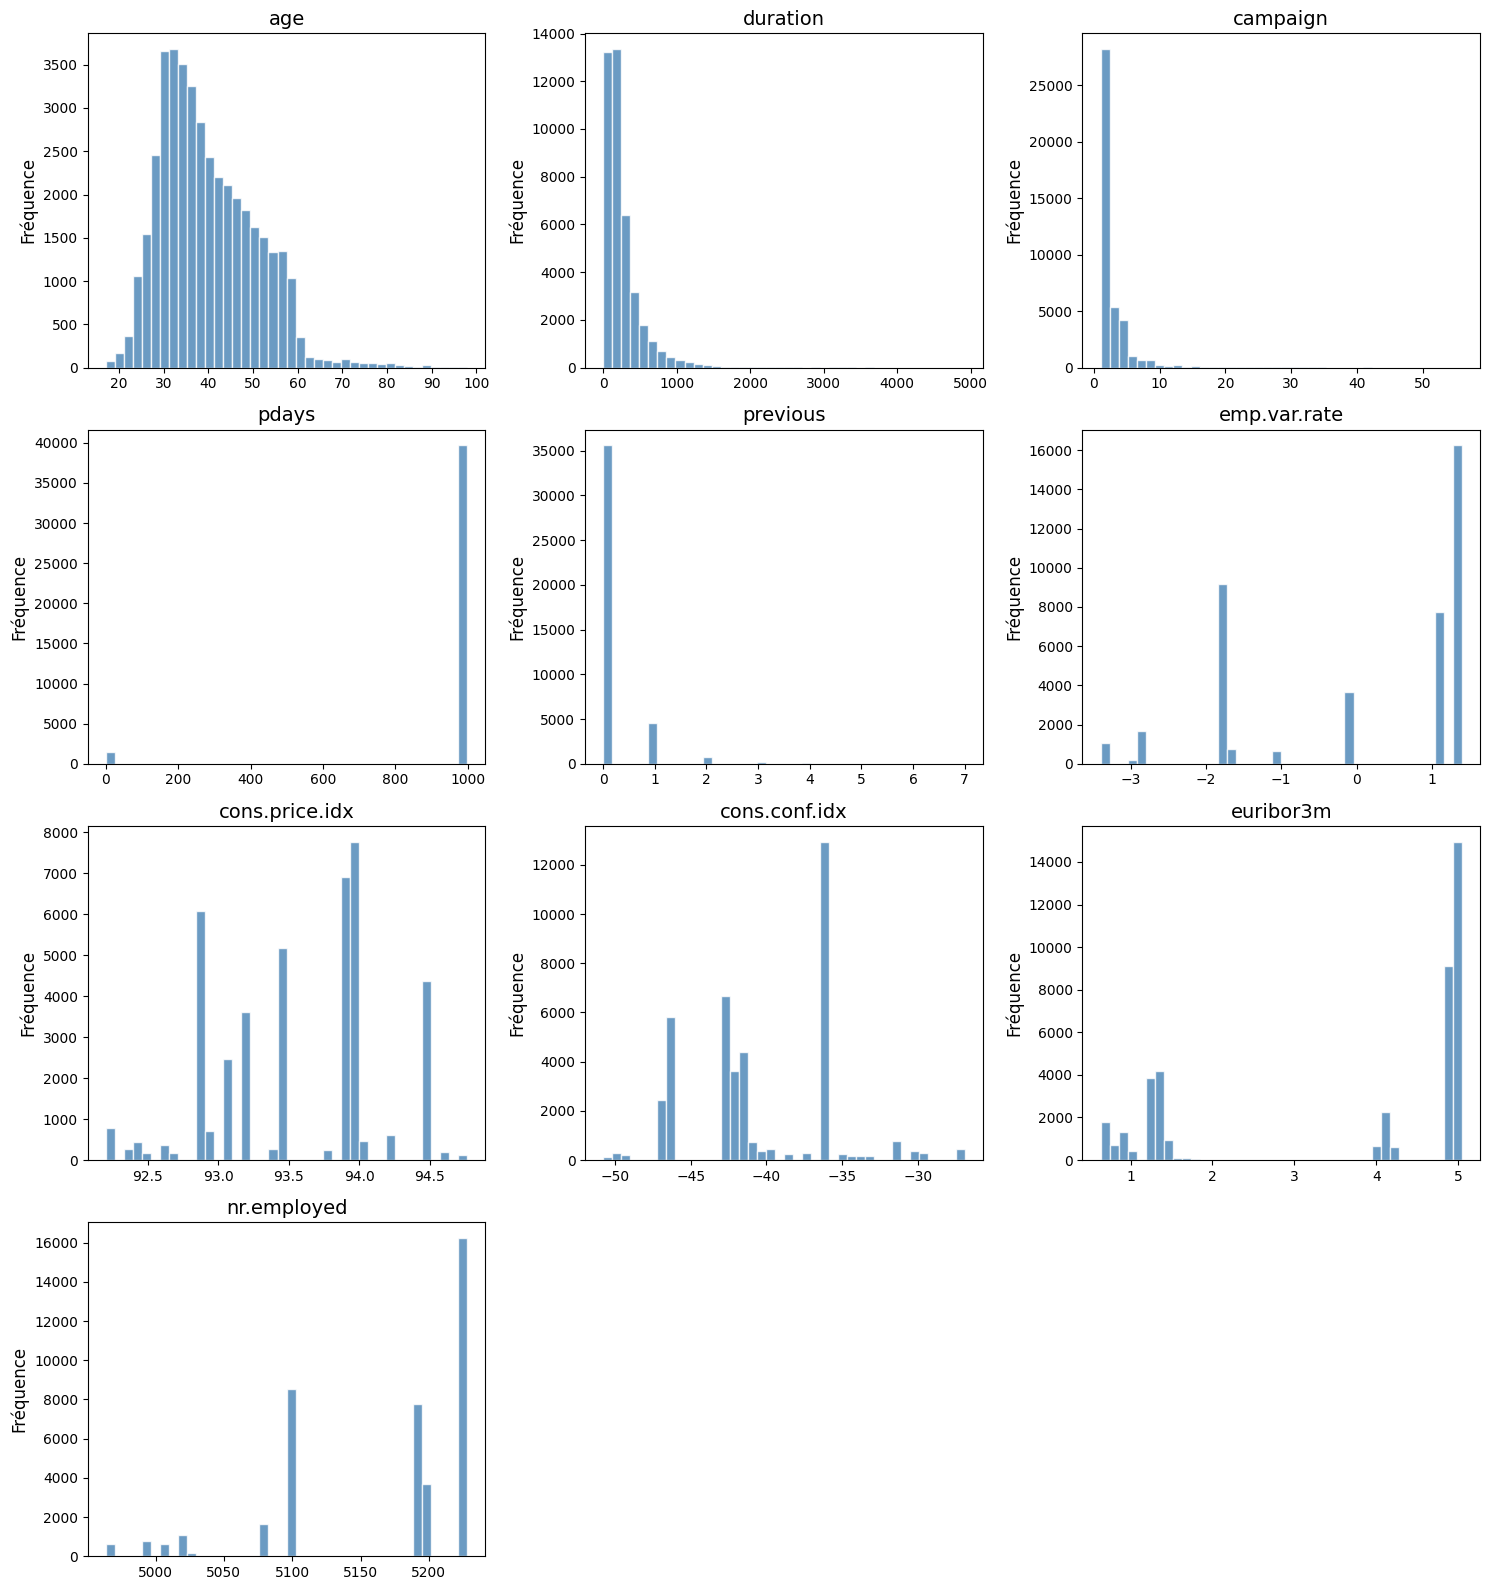

In [31]:
plot_numerical_distributions(df_add)

In [32]:
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print(df_add[econ_cols].describe().round(3).to_string())
print(f"\nCorrélations avec la cible :")
for col in econ_cols:
    corr = df_add[col].corr(y_add)
    print(f"  {col}: {corr:.4f}")

       emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
count     41188.000       41188.000      41188.000  41188.000    41188.000
mean          0.082          93.576        -40.503      3.621     5167.036
std           1.571           0.579          4.628      1.734       72.252
min          -3.400          92.201        -50.800      0.634     4963.600
25%          -1.800          93.075        -42.700      1.344     5099.100
50%           1.100          93.749        -41.800      4.857     5191.000
75%           1.400          93.994        -36.400      4.961     5228.100
max           1.400          94.767        -26.900      5.045     5228.100

Corrélations avec la cible :
  emp.var.rate: -0.2983
  cons.price.idx: -0.1362
  cons.conf.idx: 0.0549
  euribor3m: -0.3078
  nr.employed: -0.3547


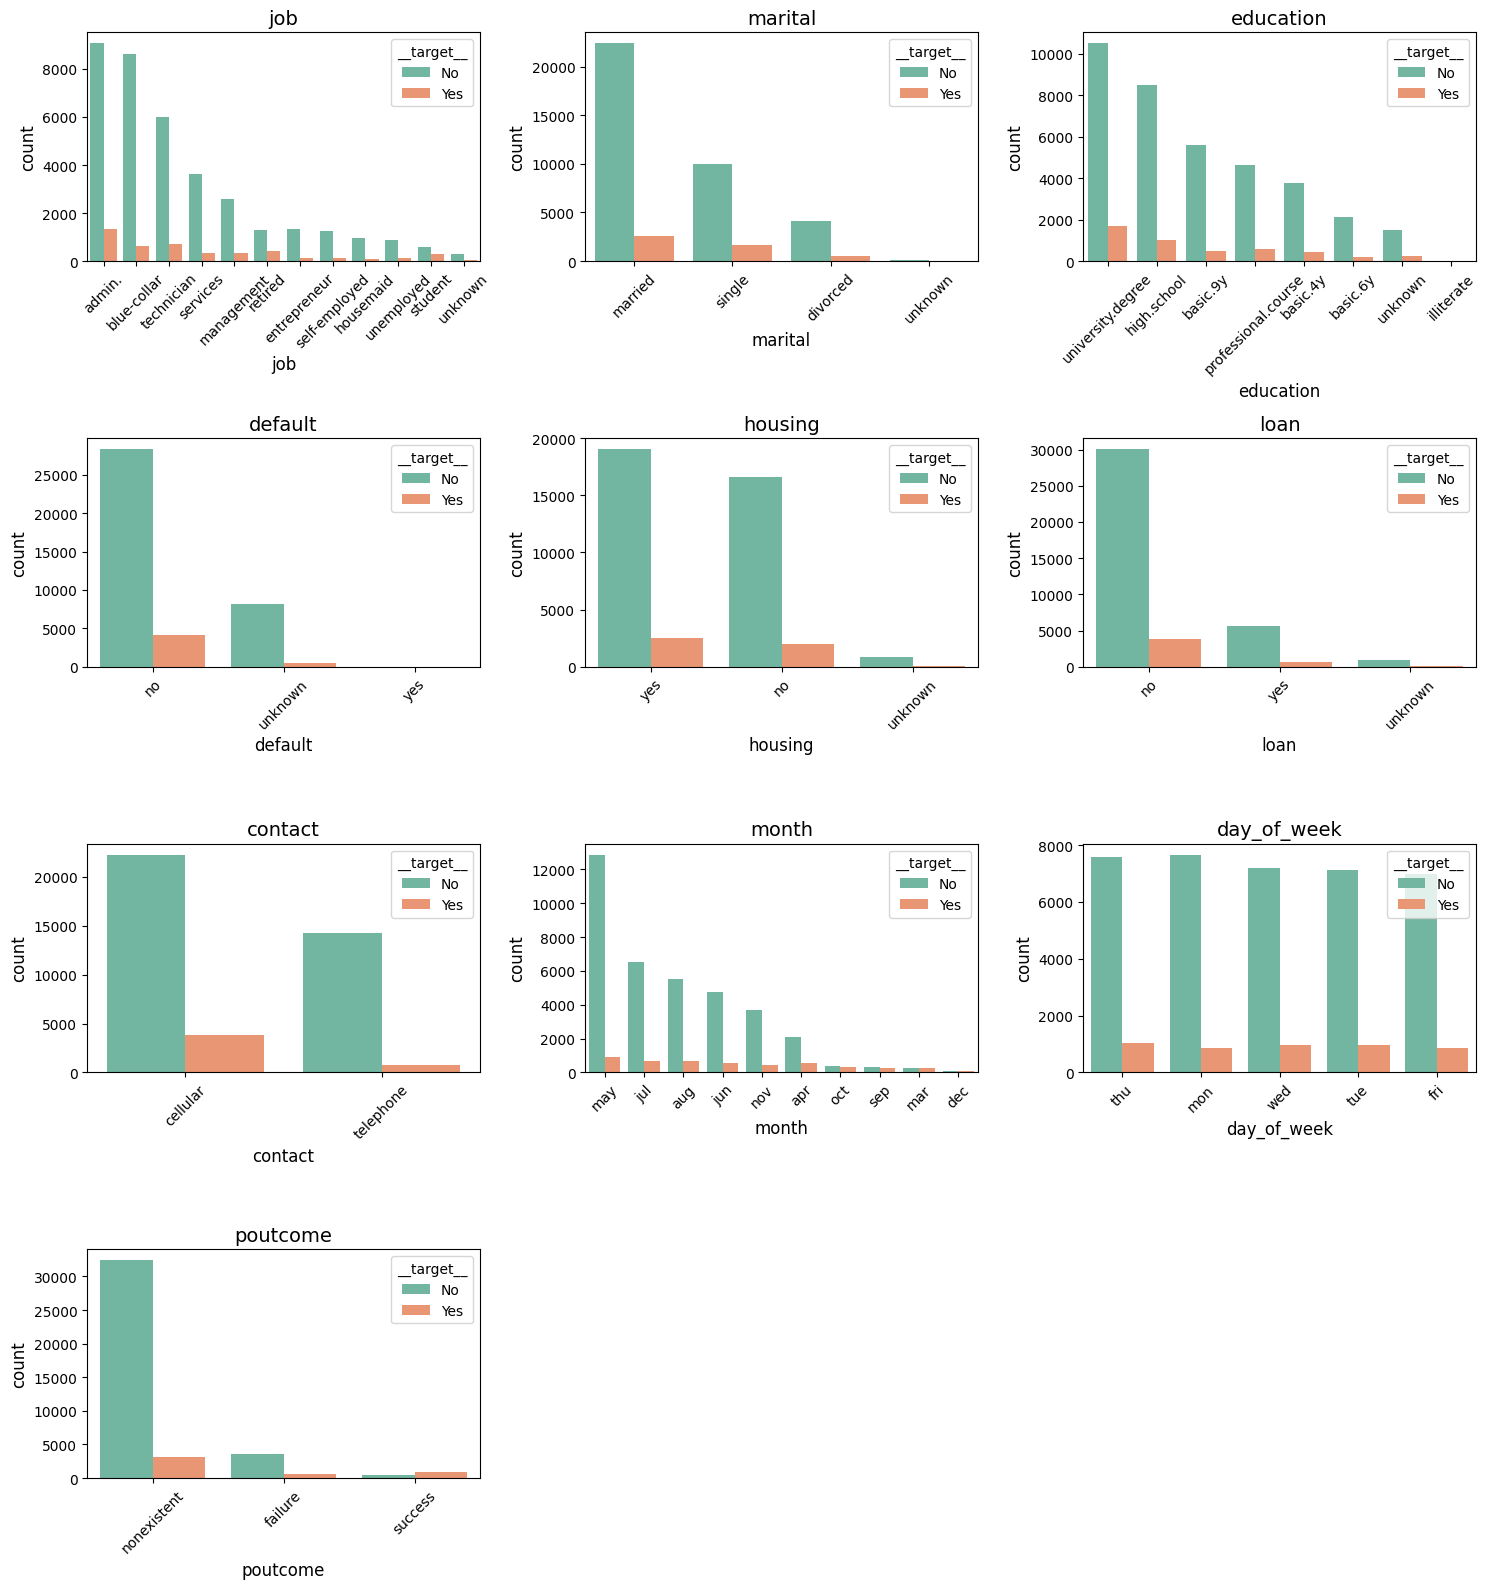

In [33]:
plot_categorical_distributions(df_add, target=y_add)

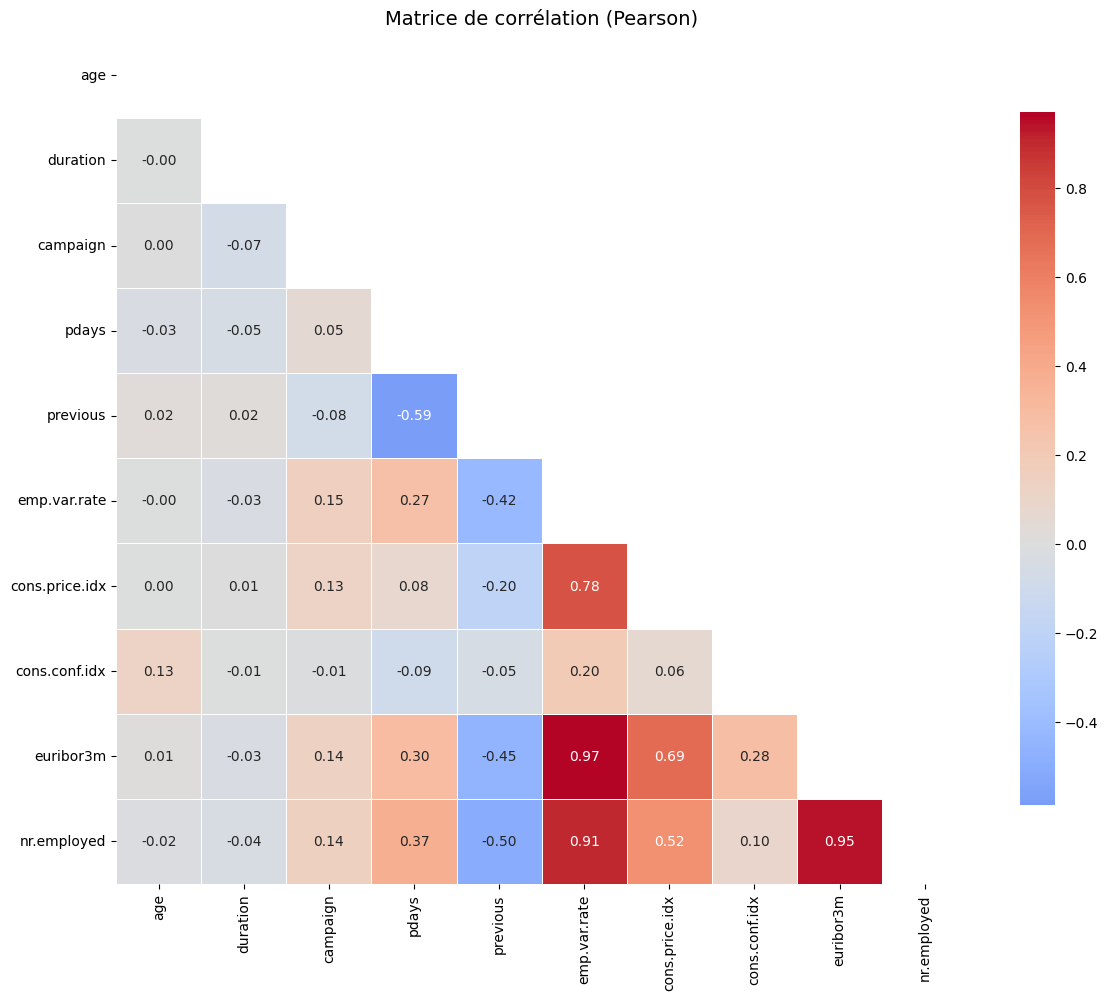

In [34]:
plot_correlation_matrix(df_add)

In [35]:
print(f"{'='*60}")
print(f"  Comparaison Bank vs Bank Additional")
print(f"{'='*60}")
print(f"Instances  — Bank: {len(df_bank):,}  |  Additional: {len(df_add):,}")
print(f"Colonnes   — Bank: {df_bank.shape[1]}  |  Additional: {df_add.shape[1]}")
print(f"\nTaux de souscription (y='yes') :")
print(f"  Bank:       {(df_bank['y'] == 'yes').sum() / len(df_bank) * 100:.2f}%")
print(f"  Additional: {(df_add['y'] == 'yes').sum() / len(df_add) * 100:.2f}%")
print(f"\nVariables communes :")
common = set(df_bank.columns) & set(df_add.columns)
print(f"  {len(common)} colonnes : {sorted(common)}")
print(f"\nVariables specifiques a Bank :")
only_bank = set(df_bank.columns) - set(df_add.columns)
print(f"  {sorted(only_bank)}")
print(f"\nVariables specifiques a Additional :")
only_add = set(df_add.columns) - set(df_bank.columns)
print(f"  {sorted(only_add)}")

  Comparaison Bank vs Bank Additional
Instances  — Bank: 45,211  |  Additional: 41,188
Colonnes   — Bank: 17  |  Additional: 21

Taux de souscription (y='yes') :
  Bank:       11.70%
  Additional: 11.27%

Variables communes :
  15 colonnes : ['age', 'campaign', 'contact', 'default', 'duration', 'education', 'housing', 'job', 'loan', 'marital', 'month', 'pdays', 'poutcome', 'previous', 'y']

Variables specifiques a Bank :
  ['balance', 'day']

Variables specifiques a Additional :
  ['cons.conf.idx', 'cons.price.idx', 'day_of_week', 'emp.var.rate', 'euribor3m', 'nr.employed']
